# Images Recognition with Gradient Boosting

[Download ipynb](https://bryantstats.github.io/math460/python/images_recognition/image_recognition_gb.ipynb)

For image recognition with Adaboost and Random Forest models, please find [this link](https://bryantstats.github.io/math460/python/images_recognition/image_recognition_ada.ipynb) and [this link](https://bryantstats.github.io/math460/python/images_recognition/image_recognition_rf.ipynb).

### Instruction

Make the following two folders.  The notebook should be in the same path as these two folders 

- `train images`: Containing few subfolders.  Each subfolder contains images of a class.  In this example, the `train images` has two subfolders: `dog` (containing `dog` images) and `cat` (containing `cat` images). 

- `test images`: Containing only images for testing.  There is NO subfolder within `test images`

-  The notebook should be in the same folder as these two above folders. 


## Import some packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import matplotlib
 
# import the necessary packages
from sklearn.model_selection import train_test_split
import os
import tkinter
from os import listdir
from PIL import Image

In [2]:
# Set image resolution
dim = 200

In [3]:
train_folder = 'train images'
test_folder = 'test images'
lab = os.listdir(train_folder)

In [4]:
# Import Images Data

Xtrain = np.empty((0,3*dim*dim), float)
ytrain = np.empty((0,), int)

for i in range(0, len(lab)): 
    path = train_folder + '/' + lab[i]
    names = [f for f in os.listdir(path)]
    for n in names[0:]:
        img = Image.open(path +'/'+ n)
        image = img.convert('RGB')
        image = image.resize((dim, dim))
        image = np.array(image)
        image = image.ravel().reshape(1,-1)
        Xtrain = np.append(Xtrain, image,0)
        ytrain = np.append(ytrain, i)  

## Training

In [5]:
# Gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

number_of_trees = 100
learning_rate = .1
depth_of_each_tree = 3 # if depth_of_each_tree=1, we have a stump!

model = GradientBoostingClassifier(n_estimators=number_of_trees, learning_rate=learning_rate, max_depth=depth_of_each_tree)
model.fit(Xtrain, ytrain)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

## Training Accuracy

In [6]:
ypred=model.predict(Xtrain)
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ypred, ytrain)
mat

array([[130,   0],
       [  0, 132]])

## Predicting New Images

In the next codes, we will use our fitted model to classify new images of dogs and cats.  The model will label as `Dog` or `Cat`. These labeled images is then save in the **predict** folder.

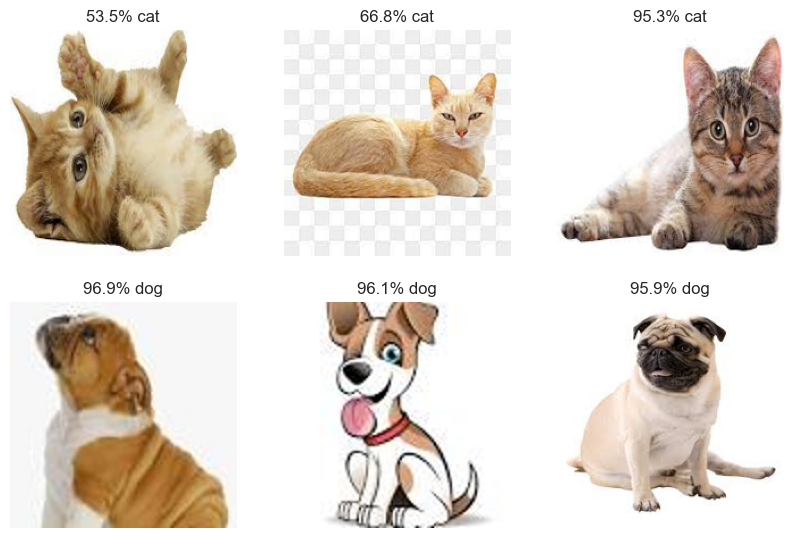

In [7]:
onlyfiles = [f for f in listdir(test_folder)]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i, images in enumerate(onlyfiles):
    
    ax = plt.subplot(int(1+len(onlyfiles)/3), 3, i + 1)
    img = Image.open(test_folder+'/'+images)
    image = img.convert('RGB')
    image = image.resize((dim, dim))
    image_print = image.resize((dim, dim))
    image = np.array(image)
    image = image.ravel().reshape(1,-1)

    predictions = model.predict(image)
    
    confidence = (100*model.predict_proba(image).max()).round(1)
    
    plt.imshow(image_print)
    plt.title(str(confidence)+'% '+lab[predictions[0]])
    plt.axis("off")